# Day 057 — K-Means Clustering


In [1]:
# Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


## 1. K-Means Clustering — Partitioning Data into K Clusters


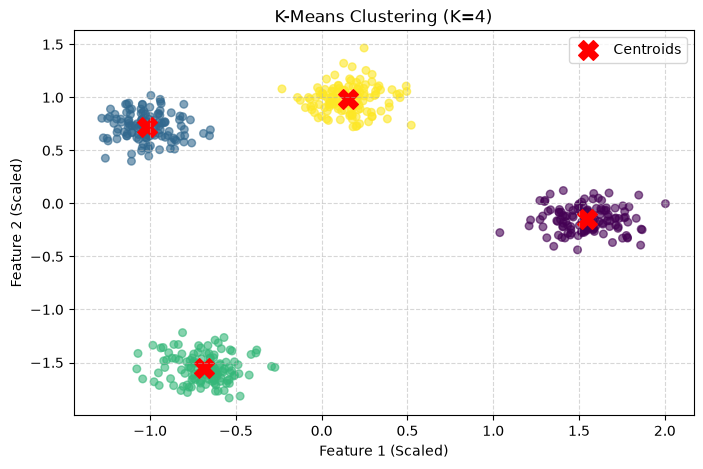

In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Generate Synthetic Data
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

# 2. Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

# 3. Visualize Clusters & Centroids
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', alpha=0.6, s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (K=4)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2. Lloyd's Algorithm — Iterative Assign-Update Convergence


In [3]:
# Custom Implementation of Lloyd's Algorithm
np.random.seed(42)
K = 4
m, n = X_scaled.shape

# Step 1: Initialize random centroids
idx = np.random.choice(m, K, replace=False)
centroids_custom = X_scaled[idx]

max_iter = 100
for iteration in range(max_iter):
    # Step 2: Assign points to nearest centroid
    distances = np.linalg.norm(X_scaled[:, np.newaxis] - centroids_custom, axis=2)
    labels_custom = np.argmin(distances, axis=1)
    
    # Step 3: Update centroids
    new_centroids = np.array([X_scaled[labels_custom == k].mean(axis=0) for k in range(K)])
    
    # Convergence check
    if np.allclose(centroids_custom, new_centroids):
        print(f"Lloyd's Algorithm Converged in {iteration + 1} iterations!")
        break
    centroids_custom = new_centroids

Lloyd's Algorithm Converged in 5 iterations!


## 3. K-Means++ Initialization — Smart Centroid Seeding


In [4]:
# Compare Random vs K-Means++ Initialization
km_random = KMeans(n_clusters=4, init='random', n_init=1, random_state=42).fit(X_scaled)
km_pp = KMeans(n_clusters=4, init='k-means++', n_init=1, random_state=42).fit(X_scaled)

print("--- Initialization Comparison ---")
print(f"Random Init Inertia: {km_random.inertia_:.2f} | Iterations: {km_random.n_iter_}")
print(f"K-Means++ Init Inertia: {km_pp.inertia_:.2f} | Iterations: {km_pp.n_iter_}")

--- Initialization Comparison ---
Random Init Inertia: 595.01 | Iterations: 6
K-Means++ Init Inertia: 18.66 | Iterations: 2


## 4. Inertia (WCSS) & Elbow Method


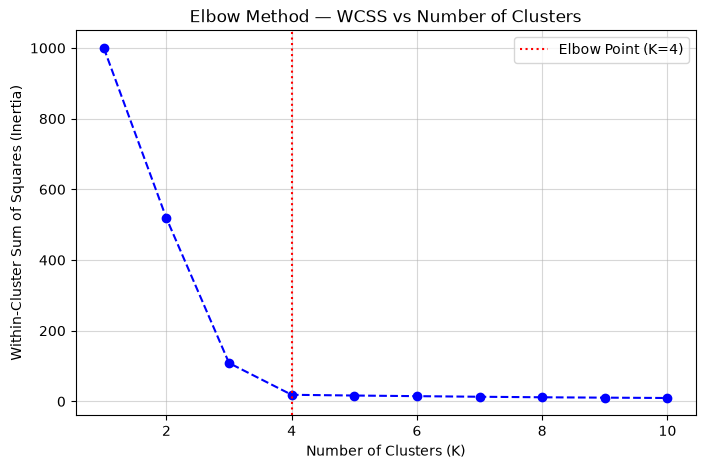

In [5]:
# Elbow Method to find optimal K
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', color='b', linestyle='--')
plt.axvline(x=4, color='r', linestyle=':', label='Elbow Point (K=4)')
plt.title("Elbow Method — WCSS vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## 5. Silhouette Score Analysis


K = 2 | Silhouette Score = 0.5727
K = 3 | Silhouette Score = 0.7667
K = 4 | Silhouette Score = 0.8393
K = 5 | Silhouette Score = 0.7117
K = 6 | Silhouette Score = 0.5781
K = 7 | Silhouette Score = 0.4601
K = 8 | Silhouette Score = 0.3518
K = 9 | Silhouette Score = 0.3486
K = 10 | Silhouette Score = 0.3547

Optimal K according to Silhouette Score: 4


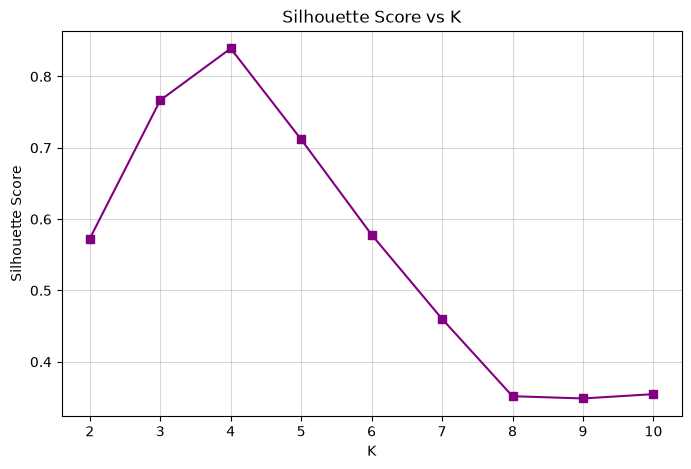

In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_eval = range(2, 11)

for k in K_eval:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k} | Silhouette Score = {score:.4f}")

best_k = K_eval[np.argmax(silhouette_scores)]
print(f"\nOptimal K according to Silhouette Score: {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(K_eval, silhouette_scores, marker='s', color='purple')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.5)
plt.show()